In [150]:
using Luxor
using Colors
using Plots
using IterTools
using DataFrames
using OpenStreetMapX
using LightOSM
using KernelDensity
using Downloads
include("../kernel_density.jl")
include("../distance.jl")
include("../prepare_data.jl")
include("../analyse.jl")
include("../plots.jl")
include("/home/adamkas/Julia/map_analyses/OSMXGraph/src/OSMXGraph.jl")
using .OSMXGraph

In [170]:
percentiles = Dict()

Dict{Any, Any}()

In [228]:
#cities1 = ["Kielce","Kraków","Warszawa","Brno","Vienna","Toronto"]
#cities2 = ["Trieste","Vilnius","Zagreb","Sofia","Sewilla","Seattle"]
#cities3 = ["San Diego","San Francisko","Sacramento","Rome", "Quebec City"]
#cities4 = ["Prague","Poznan","Pittsburgh","Ottawa","Oslo", "New York"]
#cities5 = ["Naples", "Munich", "Montreal", "Milan", "Miami", "Madrid"]
#cities6 = ["Lyon", "Los Angeles", "Lisbon","Istanbul","Hague"]
#cities7 = ["Hague","Dublin","Detroit","Denver","Dallas","Copenhagen","Chicago"] "Copenhagen"
#cities8 = ["Chicago","Budapest","Bucharest","Bratislava","Boston","Belgrad","Barcelona"]
cities9 = ["Barcelona","Baltimore","Austin", "Atlanta", "Athens","Ankara","Amsterdam"]

7-element Vector{String}:
 "Barcelona"
 "Baltimore"
 "Austin"
 "Atlanta"
 "Athens"
 "Ankara"
 "Amsterdam"

In [229]:
#cities_list = [cities1, cities2, cities3, cities4, 
#                cities5, cities6, cities7, cities8, cities9]

cities_list = [cities9]

1-element Vector{Vector{String}}:
 ["Barcelona", "Baltimore", "Austin", "Atlanta", "Athens", "Ankara", "Amsterdam"]

In [230]:
for cities in cities_list
    for ct in cities
        data = "../data"
        city = ct
        admin_level = "asd6"
        search_area = 1000
        attr = :education
        wilderness_distance = 300
        shape = "rectangle"
        calculate_percent = true
        num_of_points = 360
        distance_sectors = 200.0
        scrape_config = "../poi_config_test.csv"
        city_sector = prepare_city_map(
                    city, #city_name
                    admin_level, #admin_level
                    search_area, #search_area
                    wilderness_distance, #wilderness_distance
                    shape; #shape
                    calculate_percent = true,
                    num_of_points = num_of_points,
                    scrape_config = scrape_config,
                    dir=data)

        dir_in = "../data"
        road_types = ["motorway", "trunk", "primary", "secondary", 
                    "tertiary", "residential", "service", "living_street", 
                    "motorway_link", "trunk_link", "primary_link", "secondary_link", 
                    "tertiary_link"] 
        osm_file = "$city.osm"
        #graph_file_name = "Warszawa_graph.csv"
        #node_file_name = "Warszawa_nodes.json"
        dir_in=dir_in
        parsed = OpenStreetMapX.parseOSM(string(dir_in,"/",osm_file))
        ways = parsed.ways
        filtered_ways = OSMXGraph.filter_ways(ways,road_types)
        roads_all, road_tags, nds_all = OSMXGraph.find_all_points(filtered_ways, parsed)
        edges = OSMXGraph.ways_to_edges(roads_all,road_tags,parsed,nds_all)
        df = OSMXGraph.edges_to_df(edges)
        sparse_index = OSMXGraph.create_sparse_index(df.from_id,df.to_id,df.id)
        warsaw_center = city_sector[2]
        nodes = df[:,:from_LLA]
        rslts, center_kde = kernel_density_roads(city_sector,nodes)
        rs = vec(rslts)
        percentiles[city] = mean(center_kde .>= rs)
    end
end

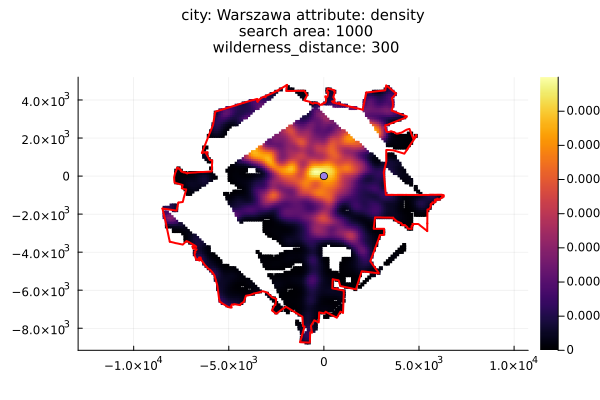

In [166]:
plot_heatmap(city_sector[1], 
            rslts, 
            city_sector[5], 
            :density, 
            "Warszawa",
            search_area,
            wilderness_distance,
            add_center=true)

In [231]:
percentiles

Dict{Any, Any} with 50 entries:
  "Chicago"       => 0.964394
  "Dallas"        => 0.986176
  "Austin"        => 0.997065
  "Istanbul"      => 0.957024
  "Madrid"        => 0.944994
  "Ottawa"        => 0.998201
  "Sofia"         => 1.0
  "Pittsburgh"    => 0.998846
  "Baltimore"     => 0.87506
  "Toronto"       => 0.976516
  "Quebec City"   => 0.998806
  "Ankara"        => 0.999515
  "Brno"          => 0.997142
  "Rome"          => 0.983573
  "Munich"        => 0.915536
  "Amsterdam"     => 0.816239
  "Detroit"       => 0.998212
  "Sacramento"    => 0.931673
  "Athens"        => 0.996671
  ⋮               => ⋮

In [232]:
cities_df = collect(keys(percentiles))
values_df = collect(values(percentiles))

50-element Vector{Any}:
 0.9643935926773456
 0.986175807663411
 0.9970654345654346
 0.9570240946878963
 0.9449939135727328
 0.9982007575757575
 1.0
 0.9988460529766588
 0.8750598659003831
 0.976515606242497
 ⋮
 0.9579373104145602
 0.762177827105685
 0.7772065801961404
 0.9959160839160839
 0.9434554303278688
 0.9213759213759214
 0.9907359752959342
 0.8965475542656751
 0.9963348765432098

In [233]:
df = DataFrame(City = cities_df, Value = values_df)

Row,City,Value
,Any,Any
1,Chicago,0.964394
2,Dallas,0.986176
3,Austin,0.997065
4,Istanbul,0.957024
5,Madrid,0.944994
6,Ottawa,0.998201
7,Sofia,1.0
8,Pittsburgh,0.998846
9,Baltimore,0.87506


In [236]:
mean(values_df)

0.94800702409256

In [237]:
CSV.write("KDE_results.csv",df)

"KDE_results.csv"